Nei codici Monte Carlo come OpenMC, i risultati dei tally sono intrinsecamente normalizzati
per particella di sorgente simulata. Nello Step 1 la tua sorgente era un singolo fotone. 
Il tally di corrente (current_a) misurava i neutroni che attraversavano la superficie esterna del target. 
Di conseguenza, la loro somma totale, ovvero sum_a, rappresenta la resa fotoneutronica integrale del bersaglio.
Fisicamente, sum_a risponde alla domanda: "Quanti neutroni utili ottengo per ogni singolo fotone 
primario emesso dal sincrotrone?" (Troverai un valore molto minore di 1, tipicamente dell'ordine di 0.01).


Dati estratti con successo.
Yield fotoneutronico calcolato (energia): 7.50804e-03 neutroni / fotone sorgente
Yield fotoneutronico calcolato (angolo): 7.50804e-03 neutroni / fotone sorgente
Yield fotoneutronico calcolato (isotropia): 5.88396e-03 neutroni / fotone sorgente


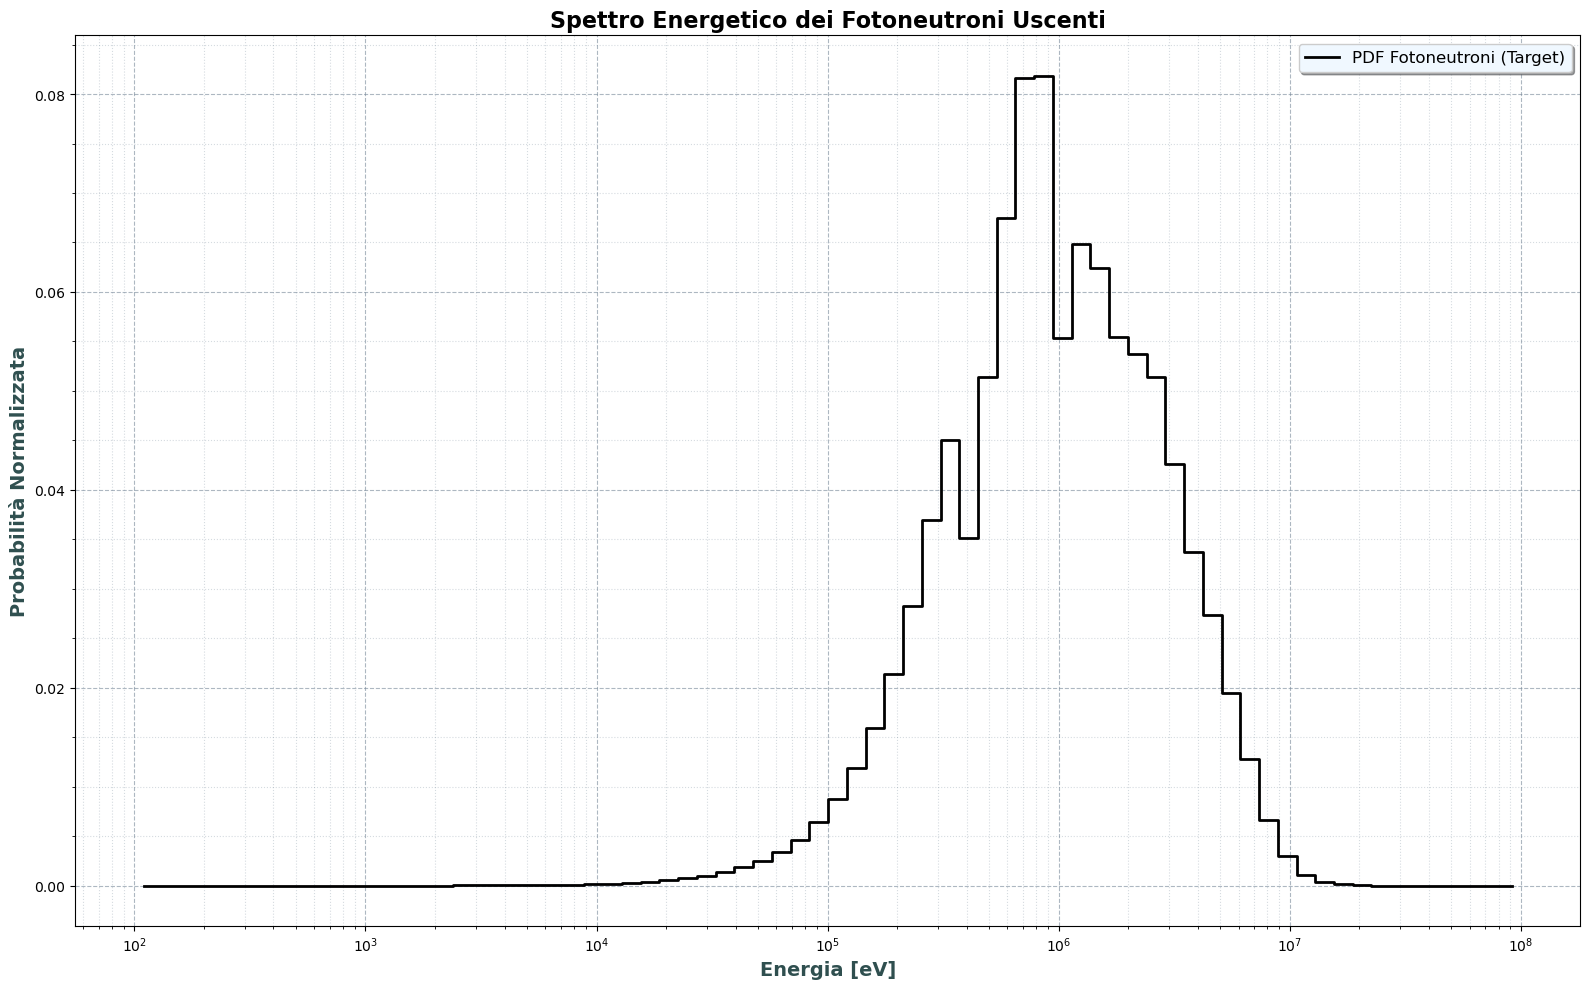

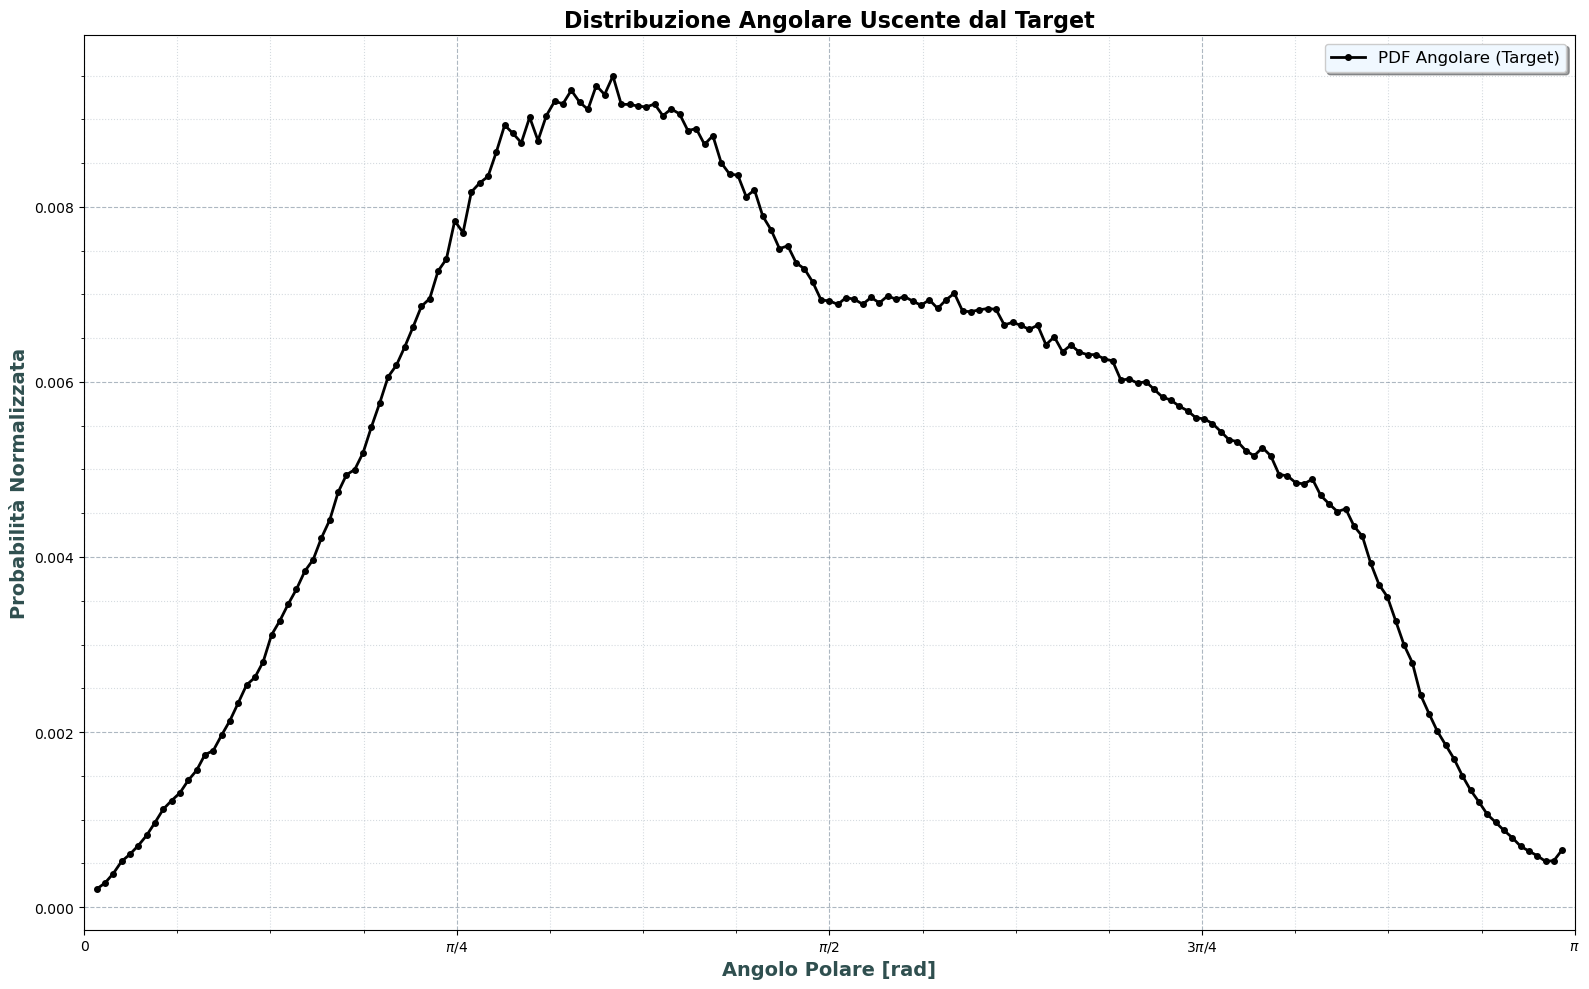

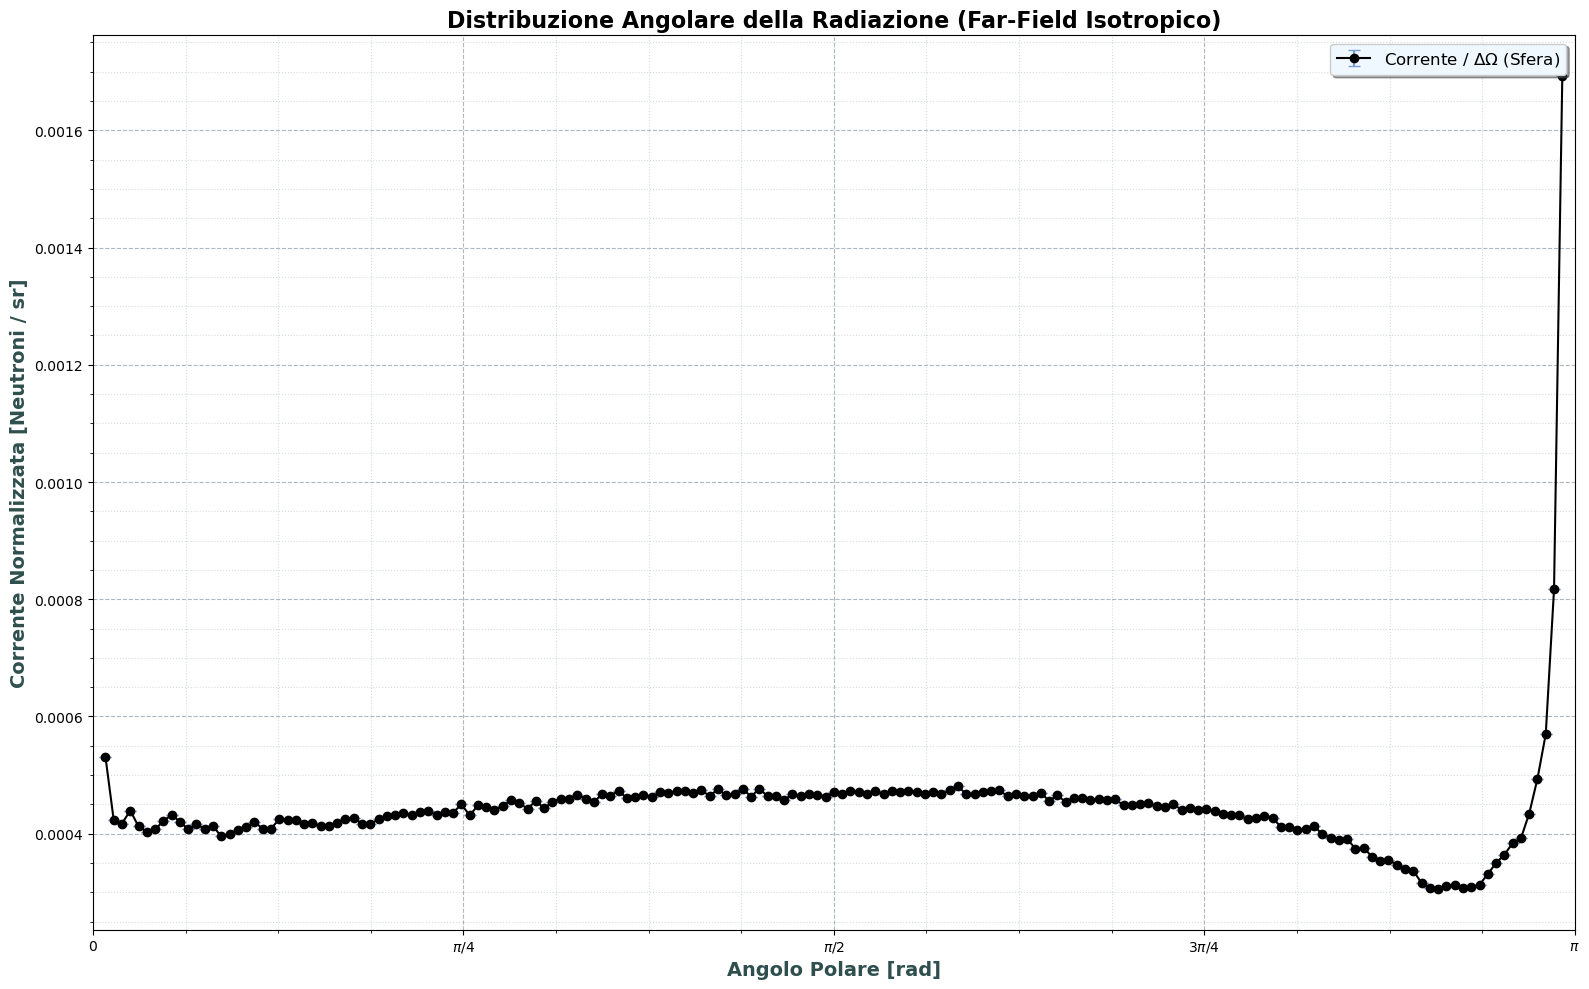

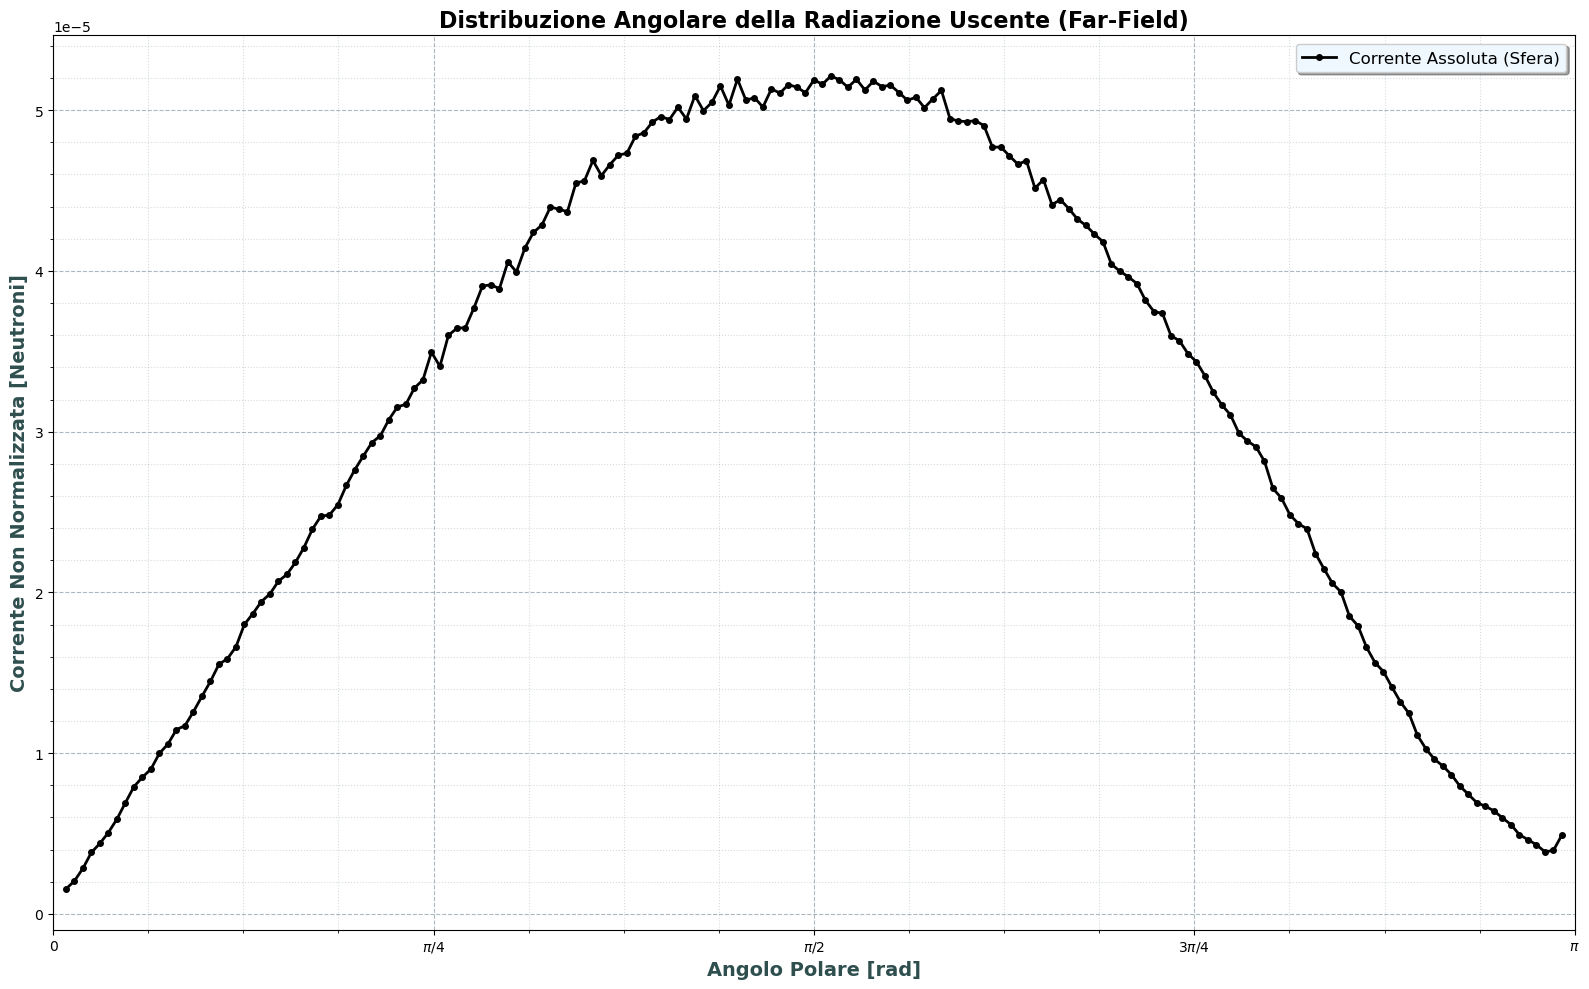

In [1]:
import os
import glob
import openmc
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. SETUP BIN E CALCOLI GEOMETRICI
# =====================================================================

energy_bins = np.logspace(2, 8, 75)
polar_bins = np.linspace(0, np.pi, 180)

# Calcolo dei centri dei bin
energy_midpoints = np.sqrt(energy_bins[:-1] * energy_bins[1:])
polar_midpoints = 0.5 * (polar_bins[:-1] + polar_bins[1:])

# Angolo solido per normalizzazione isotropia (Sfera)
solid_angles = 2 * np.pi * (np.cos(polar_bins[:-1]) - np.cos(polar_bins[1:]))

# =====================================================================
# 2. ESTRAZIONE DATI TALLIES
# =====================================================================

sp_files = glob.glob('statepoint.*.h5')
if not sp_files:
    raise FileNotFoundError("Nessun file statepoint trovato.")
latest_sp = max(sp_files, key=os.path.getctime)

with openmc.StatePoint(latest_sp) as sp:
    # --- Tally 1: Spettro Energetico (Target) ---
    # Nota: Assicurati che i nomi corrispondano esattamente a quelli definiti nel setup
    t_e = sp.get_tally(name='spettro_energia_neutroni_target')
    val_e = np.abs(t_e.mean.flatten())
    current_e = val_e.reshape(3, len(energy_midpoints)).sum(axis=0)
    
    # --- Tally 2: Spettro Angolare (Target) ---
    t_a = sp.get_tally(name='spettro_angolare_neutroni_target') 
    val_a = np.abs(t_a.mean.flatten())
    current_a = val_a.reshape(3, len(polar_midpoints)).sum(axis=0)

    # --- Tally 3: Isotropia (Sfera di controllo) ---
    t_iso = sp.get_tally(name='distribuzione_isotropia_sfera')
    current_iso = np.abs(t_iso.mean.flatten())
    std_iso = t_iso.std_dev.flatten()

# =====================================================================
# 3. YIELD E NORMALIZZAZIONI
# =====================================================================

# Lo yield totale è l'integrale della corrente uscente su tutto lo spettro (o angolo)
yield_totale_e = np.sum(current_e) 
yield_totale_a = np.sum(current_a)

# Normalizzazione a Probabilità Discreta (PMF/PDF)
pdf_e = current_e / yield_totale_e if yield_totale_e > 0 else current_e
pdf_a = current_a / yield_totale_a if yield_totale_a > 0 else current_a

# Normalizzazione sull'angolo solido per verifica isotropia
norm_iso_mean = current_iso / solid_angles
norm_iso_std = std_iso / solid_angles

print(f"Dati estratti con successo.")
print(f"Yield fotoneutronico calcolato (energia): {yield_totale_e:.5e} neutroni / fotone sorgente")
print(f"Yield fotoneutronico calcolato (angolo): {yield_totale_a:.5e} neutroni / fotone sorgente")
print(f"Yield fotoneutronico calcolato (isotropia): {np.sum(current_iso):.5e} neutroni / fotone sorgente")

# =====================================================================
# 4. PLOTTING DEI RISULTATI
# =====================================================================

polar_mid_cut = polar_midpoints[1:-1]
current_iso_cut = current_iso[1:-1]
pdf_a_cut = pdf_a[1:-1]
norm_iso_mean_cut = norm_iso_mean[1:-1]

def apply_custom_style(ax, title, xlabel, ylabel):
    """Applica lo stile standard unificato ai plot."""
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_ylabel(ylabel, fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.minorticks_on()
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
    ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

# --- PLOT 1: Spettro Energetico ---
fig1, ax1 = plt.subplots(figsize=(16, 10))
ax1.step(energy_midpoints, pdf_e, where='mid', color='#000000', lw=2, label='PDF Fotoneutroni (Target)')
ax1.set_xscale('log')
apply_custom_style(ax1, "Spettro Energetico dei Fotoneutroni Uscenti", "Energia [eV]", "Probabilità Normalizzata")
plt.tight_layout()
plt.show()

# --- PLOT 2: Spettro Angolare (Target) ---
fig2, ax2 = plt.subplots(figsize=(16, 10))
ax2.plot(polar_mid_cut, pdf_a_cut, color='#000000', lw=2, marker='o', markersize=4, label='PDF Angolare (Target)')
ax2.set_xlim(0, np.pi)
ax2.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax2.set_xticklabels(['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
apply_custom_style(ax2, "Distribuzione Angolare Uscente dal Target", "Angolo Polare [rad]", "Probabilità Normalizzata")
plt.tight_layout()
plt.show()

# --- PLOT 3: Verifica Isotropia (Sfera Far-Field) ---
fig3, ax3 = plt.subplots(figsize=(16, 10))
ax3.errorbar(polar_mid_cut, norm_iso_mean_cut, yerr=0, 
             fmt='o-', color='#000000', ecolor='#789DD1', capsize=4, 
             label=r'Corrente / $\Delta\Omega$ (Sfera)')
ax3.set_xlim(0, np.pi)
ax3.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax3.set_xticklabels(['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
apply_custom_style(ax3, "Distribuzione Angolare della Radiazione (Far-Field Isotropico)", "Angolo Polare [rad]", "Corrente Normalizzata [Neutroni / sr]")
plt.tight_layout()
plt.show()

# --- PLOT: Verifica Isotropia (Senza Poli) ---
fig3, ax3 = plt.subplots(figsize=(16, 10))

ax3.plot(polar_mid_cut, current_iso_cut, 
         color='#000000', lw=2, marker='o', markersize=4, 
         label='Corrente Assoluta (Sfera)')

# Stile Titolo e Label
ax3.set_title("Distribuzione Angolare della Radiazione Uscente (Far-Field)", fontsize=16, fontweight='bold')
ax3.set_xlabel("Angolo Polare [rad]", fontsize=14, fontweight='bold', color='#2F4F4F')
ax3.set_ylabel("Corrente Non Normalizzata [Neutroni]", fontsize=14, fontweight='bold', color='#2F4F4F')

# Assi e Tick
ax3.set_xlim(0, np.pi)
ax3.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax3.set_xticklabels(['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])

# Grid e Legend
ax3.minorticks_on()
ax3.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax3.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
ax3.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

plt.tight_layout()
plt.show()

In [2]:
#np.savetxt("photoneutrons_energy.txt", np.column_stack((energy_midpoints, pdf_e)), 
#           header="Energy_eV PDF", comments="")

#np.savetxt("photonutrons_polar.txt", np.column_stack((polar_mid_cut, pdf_a_cut)), 
#           header="Angle PDF", comments="")


Neutroni estratti dal file: 4273078


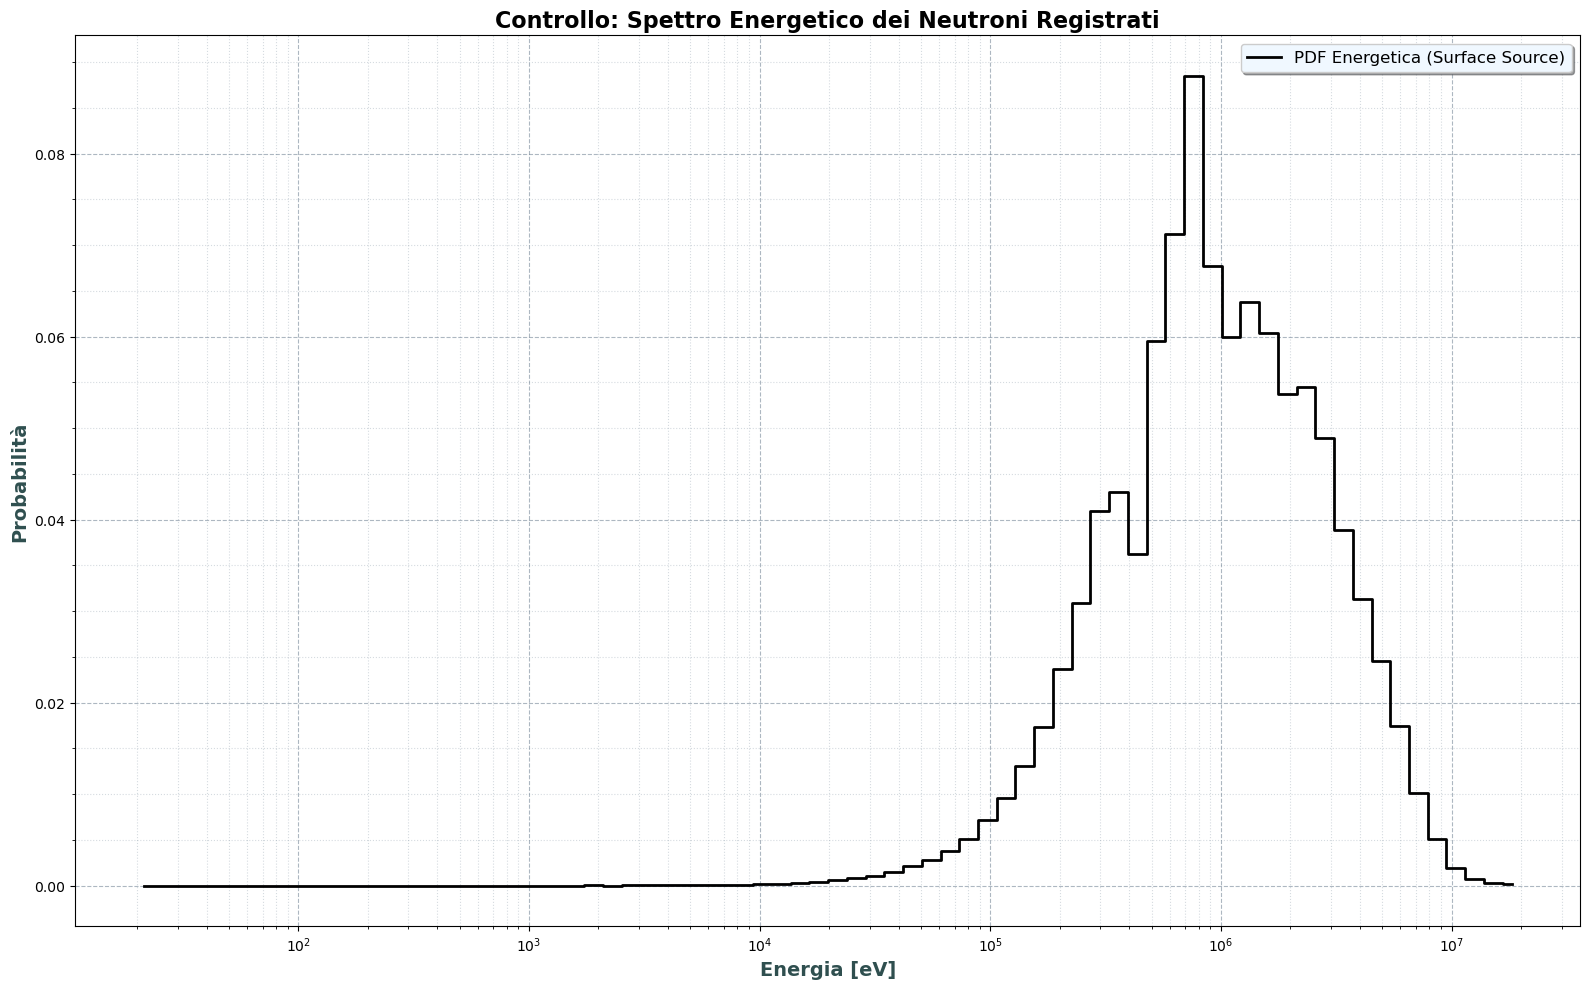

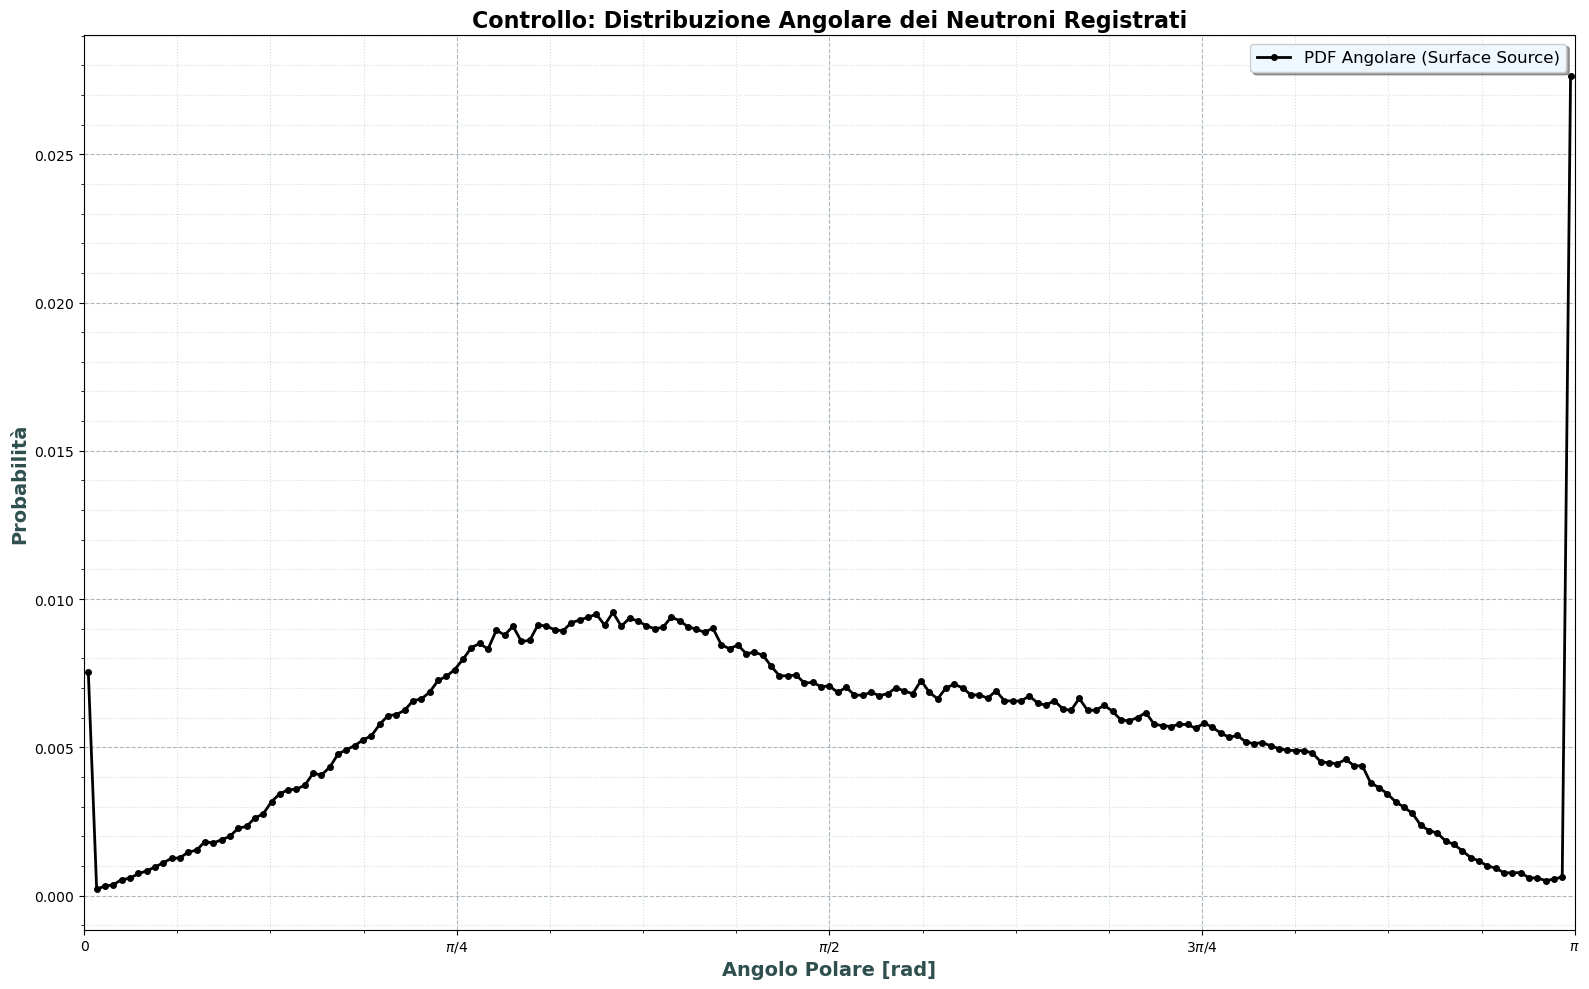

In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. LETTURA ED ESTRAZIONE DATI DA HDF5
# =====================================================================

# Apriamo il file del source_bank in sola lettura
with h5py.File('surface_source.h5', 'r') as f:
    bank = f['source_bank'][...]

# In OpenMC, l'enumeratore per i tipi di particella assegna 0 ai neutroni e 1 ai fotoni.
# Filtriamo l'array per tenere solo i neutroni.
neutrons = bank[bank['particle'] == 0]

# Estrazione Energia (in eV) e Pesi statistici
E = neutrons['E']
pesi = neutrons['wgt']

# Estrazione direzione lungo Z e conversione in angolo polare theta (radianti)
u_z = neutrons['u']['z']
# Limitiamo u_z a [-1, 1] per evitare warning numerici di arccos dovuti a precisione float
u_z = np.clip(u_z, -1.0, 1.0)
theta = np.arccos(u_z)

print(f"Neutroni estratti dal file: {len(neutrons)}")

# =====================================================================
# 2. CALCOLO DELLE DISTRIBUZIONI (BINNING)
# =====================================================================

# Spettro Energetico
energy_bins = np.logspace(np.log10(E.min()), np.log10(E.max()), 75)
hist_e, _ = np.histogram(E, bins=energy_bins, weights=pesi)
pdf_e = hist_e / np.sum(hist_e)
energy_midpoints = np.sqrt(energy_bins[:-1] * energy_bins[1:])

# Spettro Angolare
polar_bins = np.linspace(0, np.pi, 180)
hist_theta, _ = np.histogram(theta, bins=polar_bins, weights=pesi)
pdf_theta = hist_theta / np.sum(hist_theta)
polar_midpoints = 0.5 * (polar_bins[:-1] + polar_bins[1:])

# =====================================================================
# 3. PLOTTING DI CONTROLLO
# =====================================================================

def apply_custom_style(ax, title, xlabel, ylabel):
    """Applica lo stile standard unificato ai plot."""
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_ylabel(ylabel, fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.minorticks_on()
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
    ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

# --- PLOT 1: Controllo Spettro Energetico ---
fig1, ax1 = plt.subplots(figsize=(16, 10))
ax1.step(energy_midpoints, pdf_e, where='mid', color='#000000', lw=2, label='PDF Energetica (Surface Source)')
ax1.set_xscale('log')
apply_custom_style(ax1, "Controllo: Spettro Energetico dei Neutroni Registrati", "Energia [eV]", "Probabilità")
plt.tight_layout()
plt.show()

# --- PLOT 2: Controllo Distribuzione Angolare ---
fig2, ax2 = plt.subplots(figsize=(16, 10))
ax2.plot(polar_midpoints, pdf_theta, color='#000000', lw=2, marker='o', markersize=4, label='PDF Angolare (Surface Source)')
ax2.set_xlim(0, np.pi)
ax2.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax2.set_xticklabels(['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
apply_custom_style(ax2, "Controllo: Distribuzione Angolare dei Neutroni Registrati", "Angolo Polare [rad]", "Probabilità")
plt.tight_layout()
plt.show()

# se imposto sorgente monocromatica (cio che dico sotto) è vero!

Questo è un grafico fantastico e capisco perfettamente perché ti abbia lasciato dei dubbi. A prima vista, quella forma sembra nascondere un errore: i due picchi estremi a $0$ e $\pi$, e soprattutto quello strano e nettissimo "taglio a V" (notch) esattamente a metà, in corrispondenza di $\pi/2$.In realtà, il tuo script ha funzionato alla perfezione. Quello che stai osservando non è un errore numerico, ma una bellissima dimostrazione di come la geometria di un solido influenzi la corrente uscente.Ecco la spiegazione fisica e matematica di ciò che stai vedendo:1. I Picchi ai Poli (0 e $\pi$)Come avevamo anticipato, questi picchi sono fisici e legati in parte alla cinematica delle reazioni fotonucleari dirette (che sparano neutroni in avanti o all'indietro conservando la quantità di moto del fotone incidente) e in parte al fatto che i neutroni che viaggiano esattamente lungo l'asse Z attraversano le basi piane del cilindro con il cammino ottico minimo, subendo meno attenuazione.2. La "Cuspide" a $\pi/2$ (Effetto Area Proiettata)Questo è il fenomeno più interessante. La probabilità che un neutrone venga registrato dal tally incrociando il bordo del target dipende in modo cruciale dall'area proiettata del cilindro in quella specifica direzione angolare.Per un cilindro di raggio $R$ e altezza $H$, l'area proiettata vista da un angolo polare $\theta$ è la somma del contributo delle basi piatte e del mantello laterale:$$A_{proj}(\theta) = \pi R^2 |\cos(\theta)| + 2 R H \sin(\theta)$$Il contributo laterale ($2 R H \sin\theta$) è una curva morbida che ha il suo massimo a $\pi/2$.Il contributo delle basi superiori e inferiori ($\pi R^2 |\cos\theta|$) crolla a zero man mano che la traiettoria diventa orizzontale.La presenza del valore assoluto nel coseno genera matematicamente una discontinuità nella derivata (una cuspide appuntita) esattamente a $\theta = \pi/2$. In parole povere: quando l'angolo diventa esattamente di 90 gradi, le facce piatte superiore e inferiore smettono bruscamente di contribuire all'uscita dei neutroni, lasciando solo la superficie laterale. Questo brusco taglio geometrico è esattamente la "V" rovesciata che vedi al centro del tuo grafico.Perché è un'ottima notiziaQuesto plot dimostra esattamente perché non potevamo usare una PDF analitica per il secondo step. Una formula matematica liscia non avrebbe mai tenuto conto di questa interazione tra la cinematica di emissione nucleare e la discontinuità geometrica degli spigoli del cilindro. Utilizzando il surface_source.h5, i tuoi neutroni rientreranno nel nocciolo portando con sé la corretta "memoria geometrica" del target.

Neutroni post-filtraggio angolare: 4159862


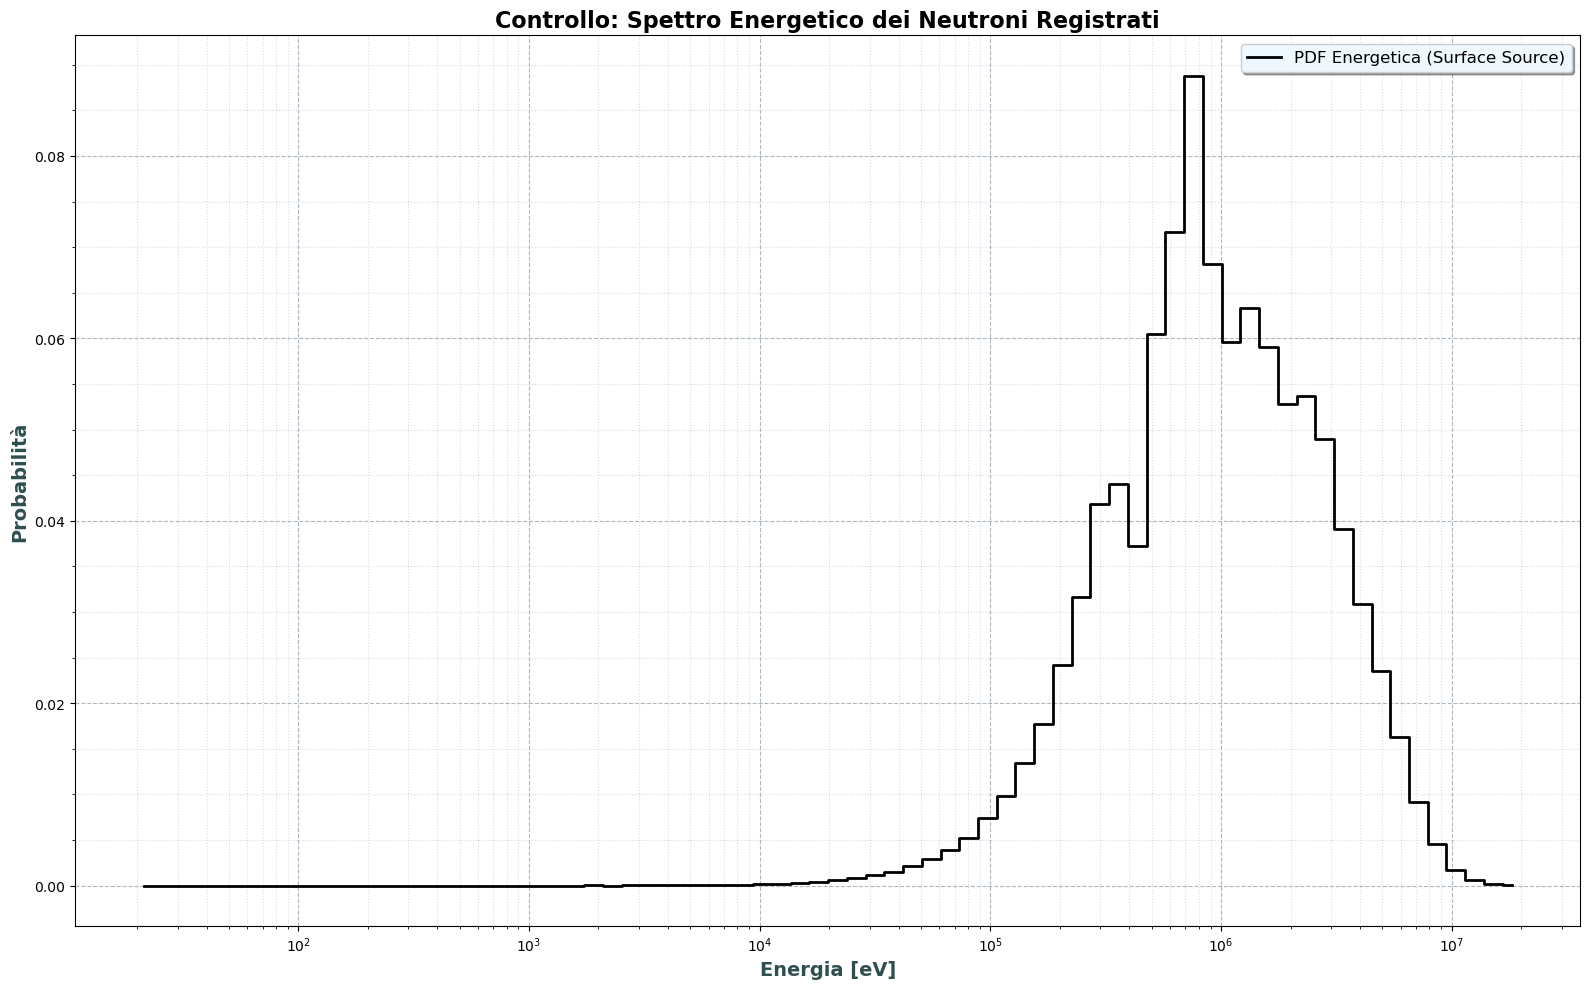

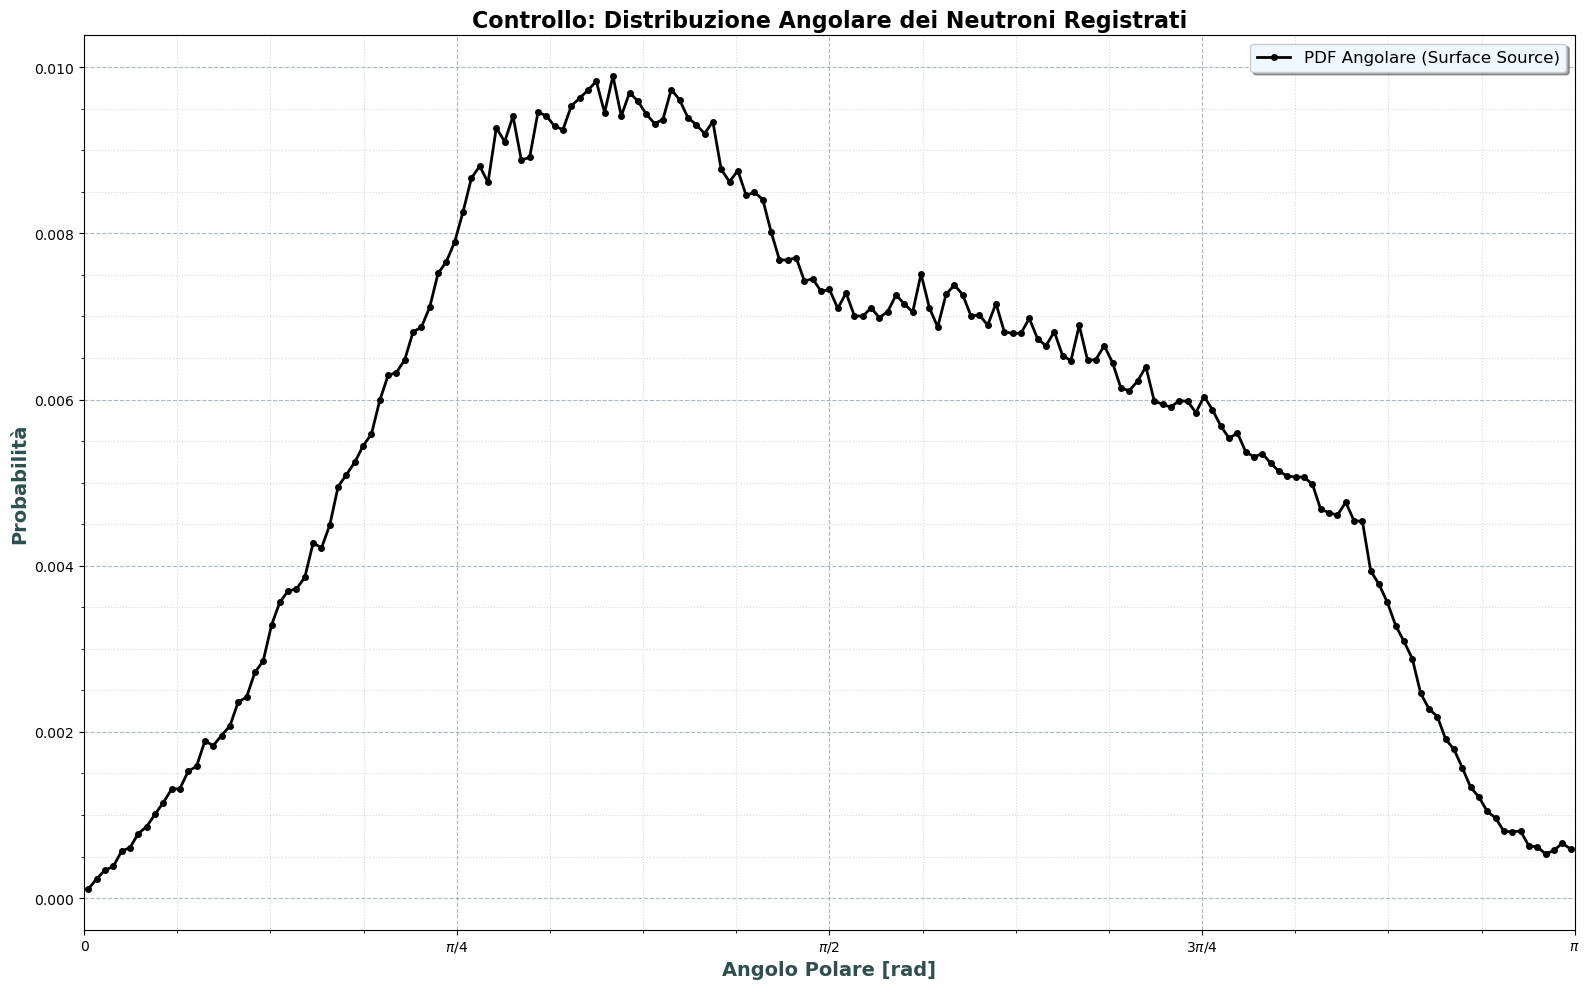

In [4]:
# ELIMINO PRIMO E ULTIMO BIN ALLA POLARE
# non mi servono ma non li elimino, il loro costo computazionale è bassissimo
import h5py
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. LETTURA ED ESTRAZIONE DATI DA HDF5
# =====================================================================

with h5py.File('surface_source.h5', 'r') as f:
    bank = f['source_bank'][...]

# Filtro per i neutroni (0 = neutroni, 1 = fotoni)
neutrons = bank[bank['particle'] == 0]

E = neutrons['E']
pesi = neutrons['wgt']
u_z = np.clip(neutrons['u']['z'], -1.0, 1.0)
theta = np.arccos(u_z)

# --- NUOVO: Filtraggio Angolare ---
# Rimozione delle particelle incidenti a 0 e 180 gradi (con tolleranza float)
epsilon = 1e-5
mask = (theta > epsilon) & (theta < (np.pi - epsilon))

E = E[mask]
pesi = pesi[mask]
theta = theta[mask]

print(f"Neutroni post-filtraggio angolare: {len(E)}")

# =====================================================================
# 2. CALCOLO DELLE DISTRIBUZIONI (BINNING)
# =====================================================================

# Spettro Energetico
energy_bins = np.logspace(np.log10(E.min()), np.log10(E.max()), 75)
hist_e, _ = np.histogram(E, bins=energy_bins, weights=pesi)
pdf_e = hist_e / np.sum(hist_e)
energy_midpoints = np.sqrt(energy_bins[:-1] * energy_bins[1:])

# Spettro Angolare
polar_bins = np.linspace(0, np.pi, 180)
hist_theta, _ = np.histogram(theta, bins=polar_bins, weights=pesi)
pdf_theta = hist_theta / np.sum(hist_theta)
polar_midpoints = 0.5 * (polar_bins[:-1] + polar_bins[1:])

# =====================================================================
# 3. PLOTTING DI CONTROLLO
# =====================================================================

def apply_custom_style(ax, title, xlabel, ylabel):
    """Applica lo stile standard unificato ai plot."""
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_ylabel(ylabel, fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.minorticks_on()
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
    ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

# --- PLOT 1: Controllo Spettro Energetico ---
fig1, ax1 = plt.subplots(figsize=(16, 10))
ax1.step(energy_midpoints, pdf_e, where='mid', color='#000000', lw=2, label='PDF Energetica (Surface Source)')
ax1.set_xscale('log')
apply_custom_style(ax1, "Controllo: Spettro Energetico dei Neutroni Registrati", "Energia [eV]", "Probabilità")
plt.tight_layout()
plt.show()

# --- PLOT 2: Controllo Distribuzione Angolare ---
fig2, ax2 = plt.subplots(figsize=(16, 10))
ax2.plot(polar_midpoints, pdf_theta, color='#000000', lw=2, marker='o', markersize=4, label='PDF Angolare (Surface Source)')
ax2.set_xlim(0, np.pi)
ax2.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax2.set_xticklabels(['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
apply_custom_style(ax2, "Controllo: Distribuzione Angolare dei Neutroni Registrati", "Angolo Polare [rad]", "Probabilità")
plt.tight_layout()
plt.show()